In [35]:
import sys
import os

sys.path.append('/home/jovyan/scripts')

from scripts.ingestion.arbeitnow_client import collect_arbeitnow, filter_new_jobs
from datetime import datetime, timedelta

raw_jobs = collect_arbeitnow(max_pages=2)

last_run = datetime.now() - timedelta(hours=48)
new_jobs = filter_new_jobs(raw_jobs, last_run)

print(f"Total jobs: {len(raw_jobs)}")
print(f"New jobs since last run: {len(new_jobs)}")

Total jobs: 200
New jobs since last run: 200


In [36]:
import pandas as pd
df = pd.DataFrame(raw_jobs)
df.head()

,slug,company_name,title,description,remote,url,tags,job_types,location,created_at
0,bereichsleitung-fachbereich-leittechnik-romerb...,INP Deutschland GmbH,Bereichsleitung (m/w/d) Fachbereich Leittechnik,<p>Als international agierende Ingenieur- und ...,False,https://www.arbeitnow.com/jobs/companies/inp-d...,[Engineering],[],Römerberg,1776339038
1,senior-go-consultant-engineer-munich-355477,CmdScale GmbH,Senior Go Consultant / Engineer (m/w/d),<p>Bei <strong>CmdScale</strong> lösen wir kom...,True,https://www.arbeitnow.com/jobs/companies/cmdsc...,"[Remote, Consulting, Engineering]",[berufserfahren],Munich,1776339038
2,senior-rust-consultant-engineer-munich-304255,CmdScale GmbH,Senior Rust Consultant / Engineer (m/w/d),<p>Bei <strong>CmdScale</strong> lösen wir kom...,True,https://www.arbeitnow.com/jobs/companies/cmdsc...,"[Remote, Consulting, Engineering]",[berufserfahren],Munich,1776339037
3,anwendungs-entwickler-erp-ottobrunn-223456,SHB Business Solutions GmbH,Anwendungs-Entwickler ERP (w/m/d),<p><strong>Deine Mission</strong> 🚀</p>\n<p>Du...,False,https://www.arbeitnow.com/jobs/companies/shb-b...,[IT],[],Ottobrunn,1776339037
4,technischer-property-manager-wohn-und-gewerbei...,Trigon Gruppe GmbH,Technischer Property Manager (w/m/d) Wohn- und...,<p>Zur Verstärkung unseres Teams in der Gebäud...,False,https://www.arbeitnow.com/jobs/companies/trigo...,"[Building, Supply, Safety Services Engineering]",[],Berlin,1776339037


In [37]:
df.isnull().sum()

slug            0
company_name    0
title           0
description     0
remote          0
url             0
tags            0
job_types       0
location        0
created_at      0
dtype: int64

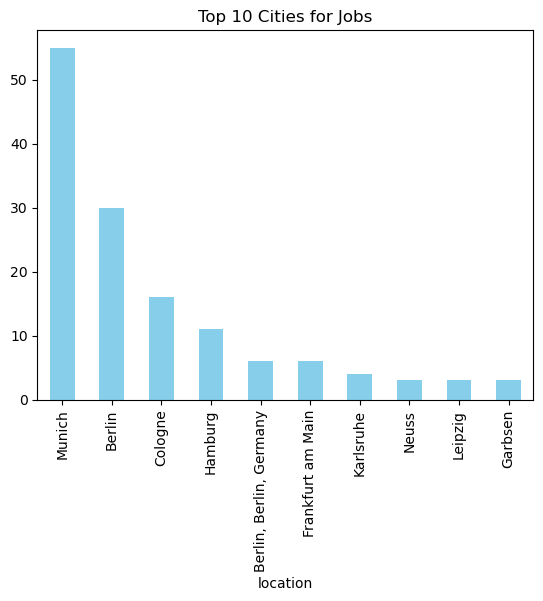

In [38]:
import matplotlib.pyplot as plt

# Chart of the top 10 cities with the most jobs
df['location'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Cities for Jobs')
plt.show()

In [39]:
df.head(1)

,slug,company_name,title,description,remote,url,tags,job_types,location,created_at
0,bereichsleitung-fachbereich-leittechnik-romerb...,INP Deutschland GmbH,Bereichsleitung (m/w/d) Fachbereich Leittechnik,<p>Als international agierende Ingenieur- und ...,False,https://www.arbeitnow.com/jobs/companies/inp-d...,[Engineering],[],Römerberg,1776339038


In [40]:
# Unpack the lists contained in the tags and calculate their frequency
all_tags = df.explode('tags')
print("Top 5 Tags:")
print(all_tags['tags'].value_counts().head(5))

Top 5 Tags:
tags
Finance                        40
Remote                         28
Marketing and Communication    23
Engineering                    17
IT                             12
Name: count, dtype: int64


In [41]:
print(f"Duplicates: {df.duplicated(subset=['slug']).sum()}")

Duplicates: 0


In [42]:
print(df.isnull().sum())

slug            0
company_name    0
title           0
description     0
remote          0
url             0
tags            0
job_types       0
location        0
created_at      0
dtype: int64


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   slug          200 non-null    object
 1   company_name  200 non-null    object
 2   title         200 non-null    object
 3   description   200 non-null    object
 4   remote        200 non-null    bool  
 5   url           200 non-null    object
 6   tags          200 non-null    object
 7   job_types     200 non-null    object
 8   location      200 non-null    object
 9   created_at    200 non-null    int64 
dtypes: bool(1), int64(1), object(8)
memory usage: 14.4+ KB


## descripton Column

In [44]:
df['description']

0      <p>Als international agierende Ingenieur- und ...
1      <p>Bei <strong>CmdScale</strong> lösen wir kom...
2      <p>Bei <strong>CmdScale</strong> lösen wir kom...
3      <p><strong>Deine Mission</strong> 🚀</p>\n<p>Du...
4      <p>Zur Verstärkung unseres Teams in der Gebäud...
                             ...                        
195    <p>Die Model Car World Group beschäftigt über ...
196    <h2>Projektbeschreibung:</h2>\n<p>Technologie ...
197    <p>The White Labels team focuses on building w...
198    <p>In dieser Rolle unterstützt du den Betrieb ...
199    <p><strong>Kaltakquise ist für dich kein Schre...
Name: description, Length: 200, dtype: object

In [45]:
# Detecting the presence of HTML tags
html_rows = df[df['description'].str.contains(r'<.*?>', na=False)]

print("Rows containing HTML:")
print(html_rows[['description']].head())

Rows containing HTML:
                                         description
0  <p>Als international agierende Ingenieur- und ...
1  <p>Bei <strong>CmdScale</strong> lösen wir kom...
2  <p>Bei <strong>CmdScale</strong> lösen wir kom...
3  <p><strong>Deine Mission</strong> 🚀</p>\n<p>Du...
4  <p>Zur Verstärkung unseres Teams in der Gebäud...


#### Problem

The extracted text contains HTML tags like `<h2>`, `<li>`, and `<p>` instead of clean text.  
This makes the content hard to read and mixes data with presentation.  
It also complicates searching and extracting useful information like skills (e.g., "Python").  
We need plain text to store and process data efficiently.

Emoji characters like 🚀 are not errors, but they are not useful for skill extraction tasks.  
In this project, we remove them to keep the text clean and focused on meaningful information such as skills and job details.

## Created_at Column

In [46]:
print(df.dtypes)

slug            object
company_name    object
title           object
description     object
remote            bool
url             object
tags            object
job_types       object
location        object
created_at       int64
dtype: object


In [47]:
df["created_at"]

0      1776339038
1      1776339038
2      1776339037
3      1776339037
4      1776339037
          ...    
195    1776245425
196    1776337143
197    1776244816
198    1776244816
199    1776243631
Name: created_at, Length: 200, dtype: int64

In [48]:
# Non-numeric or illogical values
invalid_created = df[~df['created_at'].apply(lambda x: isinstance(x, (int, float)))]

print("Invalid created_at values:")
print(invalid_created[['created_at']].head())

Invalid created_at values:
Empty DataFrame
Columns: [created_at]
Index: []


In [49]:
# Detect illogical timestamps (e.g., future or very old)
out_of_range = df[(df['created_at'] < 1000000000) | (df['created_at'] > 2000000000)]

print("Suspicious timestamps:")
print(out_of_range[['created_at']].head())

Suspicious timestamps:
Empty DataFrame
Columns: [created_at]
Index: []


#### Dataset Note

The `created_at` field is stored as a Unix timestamp (e.g., 1776249035), which is not human-readable.  
It represents the job posting date but appears as a long numeric value.  
This makes it difficult to understand and filter data (e.g., jobs posted today or this week).  
Therefore, it should be converted into a readable date format like YYYY-MM-DD.

## Tags Column

In [50]:
df['tags']

0                                        [Engineering]
1                    [Remote, Consulting, Engineering]
2                    [Remote, Consulting, Engineering]
3                                                 [IT]
4      [Building, Supply, Safety Services Engineering]
                            ...                       
195                                          [Finance]
196                             [Software Development]
197              [Internet and software, professional]
198               [Automotive, high school coursework]
199                       [Remote, Project Management]
Name: tags, Length: 200, dtype: object

In [51]:
# Are there any values ​​that are not in the list?
not_list_tags = df[~df['tags'].apply(lambda x: isinstance(x, list))]

print("Rows where tags is NOT a list:")
print(not_list_tags[['tags']].head())

Rows where tags is NOT a list:
Empty DataFrame
Columns: [tags]
Index: []


#### Tags Column

The `tags` field is stored as a list (e.g., ['Finance', 'Remote']), meaning multiple values in one cell.  
SQL databases do not handle lists easily inside a single column.  
This makes searching and filtering more complex.  
So, we convert it into a simple comma-separated string (e.g., "Finance, Remote").

## location column

In [52]:


# 1. Discovering values ​​with extra spaces
spaces_issues = df[df['location'] != df['location'].str.strip()]

print("Rows with extra spaces:")
print(spaces_issues['location'].head(), "\n")


Rows with extra spaces:
Series([], Name: location, dtype: object) 



In [53]:
# 2. Discovering values ​​that are not in a standard format (title case)
case_issues = df[df['location'] != df['location'].str.title()]

print("Rows with inconsistent casing:")
print(case_issues['location'].head(), "\n")


Rows with inconsistent casing:
56        Frankfurt am Main
70        Frankfurt am Main
88        Frankfurt am Main
118       Frankfurt am Main
152    Freiburg im Breisgau
Name: location, dtype: object 



In [54]:
#3. Displaying unique values ​​to understand chaos
print("Unique locations:")
print(df['location'].unique())

Unique locations:
['Römerberg' 'Munich' 'Ottobrunn' 'Berlin' 'Ludwigsburg' 'Gräfelfing'
 'Emsbüren' 'Cologne' 'Peine' 'Konstanz' 'Solingen' 'Neuried'
 'Bad Krozingen' 'Castrop-Rauxel' 'Karlsruhe' 'Weißensberg' 'Leipzig'
 'Essen' 'Fürth' 'Nuremberg' 'Hanover' 'Mainz' 'Willstätt' 'Marburg'
 'Frankfurt am Main' 'Düsseldorf' 'Glücksburg' 'Frankfurt' 'Radolfzell'
 'Aschaffenburg' 'Mannheim, Baden-Württemberg, Germany' 'Regen' 'Neuss'
 'Hamburg' 'Dresden' 'Garbsen' 'Berlin, Berlin, Germany' 'Bochum'
 'Garching' 'Augsburg' 'Würzburg' 'Heilbronn' 'Munich, Bavaria, Germany'
 'München, Bayern, Germany' 'Frankfurt, Hesse, Germany'
 'Düsseldorf / München' 'Detmold' 'Darmstadt' 'Rostock' 'Gundelfingen'
 'Stuttgart' 'Freiburg im Breisgau' 'Amelinghausen' 'Preußisch Oldendorf'
 'Gummersbach' 'Ismaning' 'Lage' 'Bremen' 'Kiel' 'Mülheim' 'Cloppenburg'
 'Regensburg' 'Rüsselsheim' 'München']


#### Location Column Issue

The `location` field sometimes contains inconsistent formatting such as extra spaces or mixed letter cases (e.g., "berlin", "Berlin ", "BERLIN").  

This creates problems when filtering jobs by city because identical locations are treated as different values.  
To ensure consistency and accurate search results, we standardize the data using `.strip()` to remove spaces and `.title()` to unify the format.

## url Column

In [55]:
df['url'].duplicated().sum()

0

In [56]:
df.describe(include='all')

,slug,company_name,title,description,remote,url,tags,job_types,location,created_at
count,200,200,200,200,200,200,200,200,200,2.000000e+02
unique,200,125,187,192,2,200,64,31,64,NaN
top,bereichsleitung-fachbereich-leittechnik-romerb...,OPUS ONE Recruitment GmbH,Geschäftsführungsassistenz / Executive Assista...,"<p>Du möchtest flexibel, schnell und breit arb...",False,https://www.arbeitnow.com/jobs/companies/inp-d...,[Finance],[],Munich,NaN
freq,1,31,6,3,172,1,38,101,55,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.776293e+09
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.581945e+04
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.776244e+09
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.776258e+09
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.776297e+09
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.776328e+09


##### Data Quality Issues and Cleaning Plan

##### 1. Tags Column
The `tags` field sometimes contains empty lists `[]`, which means no skills or categories were extracted for those jobs.  
This reduces the usefulness of the data for analysis and skill extraction.

**What to do:**
- Replace empty lists with `NaN` or missing values.
- Alternatively, try extracting missing tags from the `description` field.

---

##### 2. Job Types Column
The `job_types` field also contains many empty lists `[]`, meaning the job type information is missing.

**What to do:**
- Convert empty lists to `NaN`.
- If possible, infer job type from other fields or source data.



##### 3. Location Column
The `location` field contains inconsistent formatting such as extra spaces or different letter cases (e.g., "berlin", "Berlin ", "BERLIN").

**What to do:**
- Remove extra spaces using `.strip()`
- Normalize text using `.title()` to ensure consistency.
